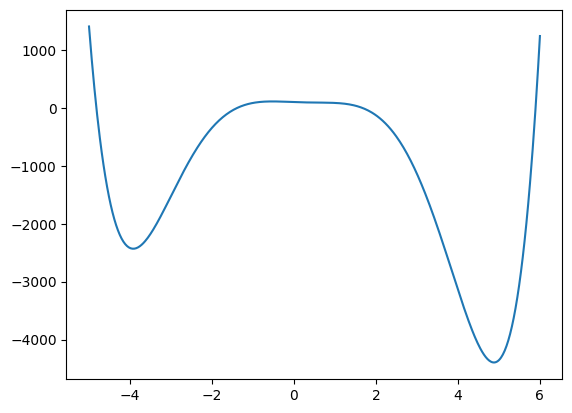

In [90]:
import optuna as op
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

def f(x):
    return x**6 - 2*x**5 - 28*x**4+28*x**3+12*x**2-26*x+100

x = np.linspace(-5,6, 500)
plt.plot(x, f(x))

In [105]:
study = op.study.create_study()

def objective(trial: op.Trial):
    x = trial.suggest_float('x', -5, 6)
    return f(x)

study.optimize(objective, n_trials=200)

[I 2026-03-31 12:29:57,573] A new study created in memory with name: no-name-3bd20c26-f99d-4e4d-a4e2-337eb7e300c0
[I 2026-03-31 12:29:57,574] Trial 0 finished with value: 99.29346275194214 and parameters: {'x': 0.02754662192472379}. Best is trial 0 with value: 99.29346275194214.
[I 2026-03-31 12:29:57,574] Trial 1 finished with value: -3787.345453526322 and parameters: {'x': 5.312385589947141}. Best is trial 1 with value: -3787.345453526322.
[I 2026-03-31 12:29:57,575] Trial 2 finished with value: -2398.037622232153 and parameters: {'x': -3.779120169413495}. Best is trial 1 with value: -3787.345453526322.
[I 2026-03-31 12:29:57,576] Trial 3 finished with value: 110.66844033373044 and parameters: {'x': -0.5783503983997503}. Best is trial 1 with value: -3787.345453526322.
[I 2026-03-31 12:29:57,576] Trial 4 finished with value: 284.94150842227043 and parameters: {'x': -4.861455172394823}. Best is trial 1 with value: -3787.345453526322.
[I 2026-03-31 12:29:57,576] Trial 5 finished with va

{'x': 4.875252800453391}


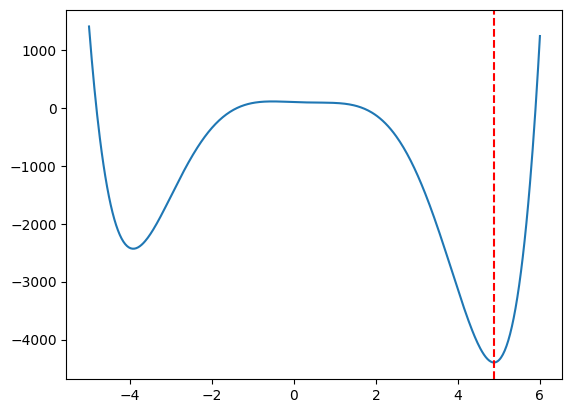

In [106]:
bestx = study.best_params
print(bestx)
plt.plot(x, f(x))
plt.axvline(bestx['x'], linestyle='--', color = 'red')

Text(0, 0.5, 'Frequency')

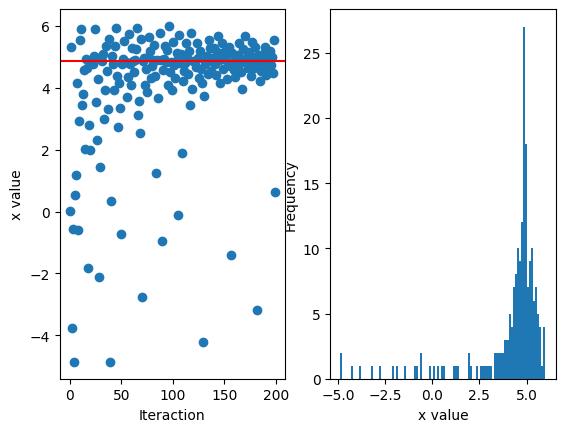

In [107]:
xs = study.trials_dataframe()

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(xs.number, # passo epoche 
            xs.params_x) # e valori
ax1.axhline(bestx['x'], color='red')
ax1.set_xlabel('Iteraction')
ax1.set_ylabel('x value')

ax2.hist(xs.params_x, bins=100)
ax2.set_xlabel('x value')
ax2.set_ylabel('Frequency')